In [1]:
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
import re
import os
import timeit
import warnings
warnings.filterwarnings('ignore')
import scanpy as sc
import torch
import pandas as pd
import argparse
import random
from matplotlib.lines import Line2D


In [2]:



def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Access the data directory
seed = 0
set_seed(seed)


activation_matrix= torch.zeros(4, 5000) 
q = 0.4# fraction shuffled
max_  = 2.5

num_shuffled = int(5000 * q)
common_activations =  torch.rand((5000)) * max_ 

# common activations 
activation_matrix[0, :] =  common_activations
activation_matrix[1, :] =  common_activations
activation_matrix[2, :] =  common_activations
activation_matrix[3, :] =  common_activations
#activation_matrix += torch.randn((4, 5000)) 

# random resampling for shuffled values
rand_ind = random.sample(list(range(5000)), num_shuffled) 
activation_matrix[0, rand_ind] =   torch.rand((num_shuffled)) * max_ 
rand_ind = random.sample(list(range(5000)), num_shuffled)
activation_matrix[1, rand_ind] =   torch.rand((num_shuffled)) * max_ 
rand_ind = random.sample(list(range(5000)), num_shuffled)
activation_matrix[2, rand_ind] =   torch.rand((num_shuffled)) *  max_ 
rand_ind = random.sample(list(range(5000)), num_shuffled)
activation_matrix[3, rand_ind] =   torch.rand((num_shuffled)) * max_ 

activation_matrix = activation_matrix.abs()


factor_loadings = torch.zeros(4, 2000)
factor_loadings[0,0:200] =  torch.rand((200)) * max_ + 0.5
factor_loadings[1,500:700] =  torch.rand((200)) * max_ + 0.5
factor_loadings[2,1000:1200] =  torch.rand((200)) * max_ + 0.5 
factor_loadings[3,1500:1700] =  torch.rand((200)) * max_ + 0.5

factor_loadings = factor_loadings.abs() 

gene_set_info = torch.zeros(4, 2000)
gene_set_info[0,0:200] =  torch.ones((200)) * 2
gene_set_info[1,500:700] =  torch.ones((200)) * 2
gene_set_info[2,1000:1200] =  torch.ones((200)) * 2
gene_set_info[3,1500:1700] =  torch.ones((200)) * 2
# data is lambda in the documentation
data = factor_loadings.T @ activation_matrix 
data += (torch.randn(2000, 5000)*(0.1)- 0.05) * max_
data = data.abs()
data_ = data # saved for log count data
data = (data.T/data.T.sum(axis = 1, keepdim = True)) * torch.ones(5000).log_normal_(mean=11.0, std=0.2).unsqueeze(dim=1)

X_pois =  torch.poisson(data)

adata = ad.AnnData(X=X_pois.detach().numpy())


for fac in [0,1,2,3]:
    adata.obs['steps_' +str(fac+1)] = activation_matrix[fac,:].detach().numpy() 


for fac in [0,1,2,3]: # if gene_set_is_zero element then 1 or else gene_set_is_zero value
    
    adata.var['DEFac_' +str(fac+1)] = (gene_set_info.T[:, fac] + (gene_set_info.T[:, fac] == 0)*1).detach().numpy()

#X_pois = (X_pois/X_pois.sum(axis = 1, keepdim = True))  * torch.ones(5000).log_normal_(mean=11.0, std=0.2).unsqueeze(dim=1)

adata.layers['counts'] = X_pois.numpy()

adata.uns['activations'] =  activation_matrix.detach().numpy()
adata.uns['loadings'] =  factor_loadings.T.detach().numpy()
adata.obs['lb_size'] = X_pois.sum(axis =1) 
median_lb_size = torch.median(X_pois.sum(axis = 1).T)

adata.layers['logcounts'] = data_.T.detach().numpy() #

adata.layers['logcounts_md_log_norm'] =torch.log2(((X_pois.T / X_pois.sum(axis = 1)).T * median_lb_size  ) + 1).detach().numpy()


num_facs = 4
num_cells = 5000
num_genes = 2000



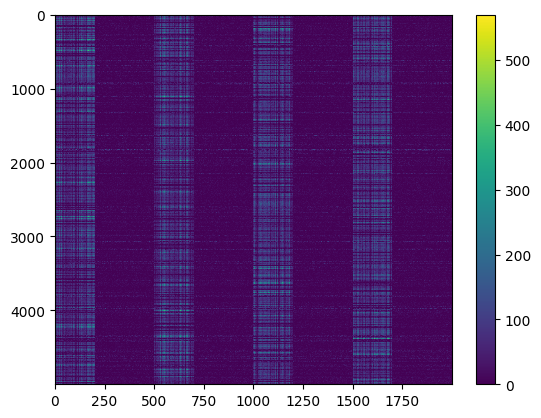

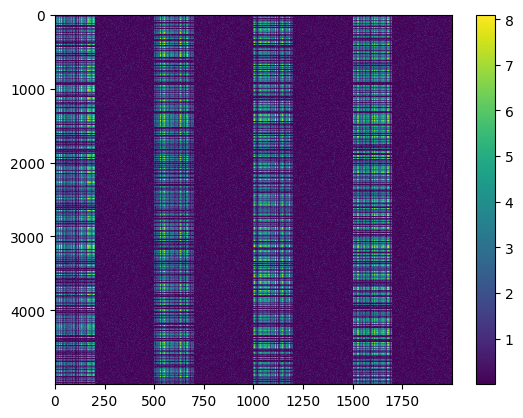

In [4]:
plt.imshow(adata.X, aspect ='auto', interpolation ='none')
plt.colorbar()
plt.show()
plt.imshow(adata.layers['logcounts'], aspect ='auto', interpolation ='none')
plt.colorbar()
plt.show()

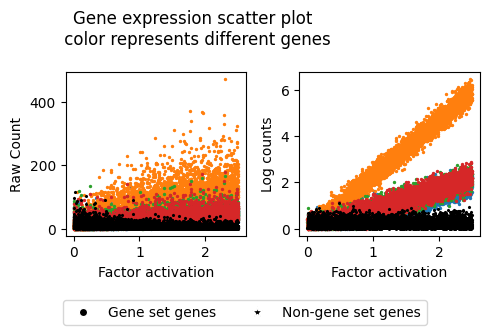

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))  # adjust size as needed
fig.text(0.4, 1.0, 'Gene expression scatter plot \n color represents different genes', ha='center', fontsize=12)

# Plot gene set genes (first 5)
for i in range(4):
    axes[0].scatter(adata.uns['activations'][0, :], adata.layers['counts'][:, i], s=2)
    axes[1].scatter(adata.uns['activations'][0, :], adata.layers['logcounts'][:, i], s=2)

# Plot non-gene set genes (201–204) in black stars
for i in range(200,201):
    axes[0].scatter(adata.uns['activations'][0, :], adata.layers['counts'][:, i], s=2, marker='*', c='k')
    axes[1].scatter(adata.uns['activations'][0, :], adata.layers['logcounts'][:, i], s=2, marker='*', c='k')

# Set titles and labels
axes[0].set_xlabel("Factor activation")
axes[0].set_ylabel("Raw Count")

axes[1].set_xlabel("Factor activation")
axes[1].set_ylabel("Log counts")

# Create custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Gene set genes',
           markerfacecolor='k', markersize=6),
    Line2D([0], [0], marker='*', color='w', label='Non-gene set genes',
           markerfacecolor='k', markersize=8)
]

# Add legend to the right of the second axis
fig.legend(handles=legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.15))
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle
plt.savefig('figures/sim_linear_gene_expression_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

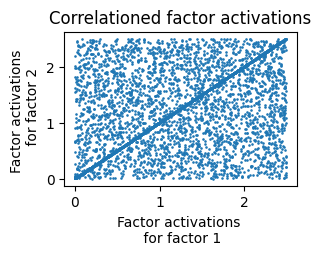

In [6]:
plt.figure(figsize=(3, 2)) 

plt.scatter(adata.uns['activations'][0, :], adata.uns['activations'][1, :], s=0.75)
plt.xlabel('Factor activations \n for factor 1')
plt.ylabel('Factor activations \n for factor 2')
plt.title('Correlationed factor activations')
plt.savefig('figures/sim_linear_correlated_factor_activations.png', dpi=300, bbox_inches='tight')
plt.show()

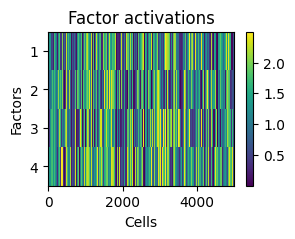

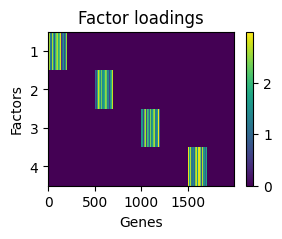

In [7]:
plt.figure(figsize=(3, 2)) 
plt.imshow(activation_matrix, aspect= 'auto', interpolation ='none')
plt.ylabel('Factors')
plt.title('Factor activations')
plt.xlabel('Cells')
plt.colorbar()

plt.yticks([0, 1, 2, 3], [1, 2, 3, 4])
plt.savefig('figures/sim_linear_factor_activations.png', dpi=300, bbox_inches='tight')

plt.show()

plt.figure(figsize=(3, 2)) 

plt.imshow(factor_loadings, aspect= 'auto', interpolation ='none')
plt.ylabel('Factors')
plt.title('Factor loadings')
plt.xlabel('Genes')
plt.yticks([0, 1, 2, 3], [1, 2, 3, 4])
plt.colorbar()
plt.savefig('figures/sim_linear_factor_loading.png', dpi=300, bbox_inches='tight')

plt.show()